# Hybrid physics + ML: training neural DAEs

Many models are *part physics, part data*: a set of conservation laws or a
dynamic (ODE/DAE) model in which one term — a reaction rate, a transport
coefficient, a closure — is unknown and must be learned from data. This notebook
shows how to train such a **hybrid model** in discopt using the *simultaneous*
approach of {cite:t}`Lueg2025`: discretize the dynamics with orthogonal
collocation, make the neural-network weights and the discretized states *joint*
decision variables, and solve the whole thing as one sparse nonlinear program.

Unlike the classic neural-ODE approach {cite:p}`Chen2018`, which differentiates
through an ODE integrator at every training step, the simultaneous approach
{cite:p}`Biegler2010` never calls an integrator: the collocation equations
enforce the dynamics *as algebraic constraints*, and a single NLP solve fits the
weights and reconstructs the state trajectory at once.

discopt gives you two halves of one story:

- **Train** a surrogate whose weights are decision variables
  (`discopt.nn.TrainableNetwork` / `TrainableKernelExpansion`) — this notebook.
- **Freeze** the trained surrogate into the frozen-embedding path
  (`discopt.nn.add_predictor`, following OMLT {cite:p}`Ceccon2022` and
  {cite:p}`Anderson2020`) and optimize *over* it with global guarantees
  {cite:p}`Schweidtmann2019` — the last section closes this loop.


## A batch-reactor problem

Consider an isothermal batch reactor $A \to B$ whose true kinetics are unknown to
us:

$$\frac{dc_A}{dt} = -r(c_A), \qquad \frac{dc_B}{dt} = +r(c_A),$$

with a Michaelis–Menten-like true rate $r(c) = 1.5\,c^2 / (0.3 + c)$. We observe
noisy concentrations of both species and want to **learn $r$** while
reconstructing the trajectories. The physics (the stoichiometric mass balances)
is known; only the rate law is replaced by a trainable surrogate.


In [1]:
import numpy as np
from scipy.integrate import solve_ivp

CA0, CB0, TF = 1.0, 0.0, 2.0
NOISE = 0.01


def r_true(c):
    return 1.5 * c**2 / (0.3 + c)


def make_data(seed, ca0=CA0, n_obs=15):
    rng = np.random.default_rng(seed)
    t = np.linspace(0.05, TF, n_obs)
    sol = solve_ivp(lambda t, y: [-r_true(y[0]), r_true(y[0])],
                    (0, TF), [ca0, CB0], t_eval=t, rtol=1e-10, atol=1e-12)
    yA = sol.y[0] + NOISE * rng.standard_normal(n_obs)
    yB = sol.y[1] + NOISE * rng.standard_normal(n_obs)
    return t, yA, yB


t_data, yA, yB = make_data(seed=0)
print(f"{len(t_data)} noisy observations of cA and cB on [0, {TF}]")

15 noisy observations of cA and cB on [0, 2.0]


## Build the hybrid model

We replace the unknown rate law with a small feedforward network
(`TrainableNetwork`) whose weights are *decision variables*. The dynamics are
transcribed with orthogonal collocation on finite elements via
`discopt.dae.DAEBuilder`; the network is simply called inside the ODE right-hand
side, so its weights enter the collocation constraints directly.

We use a **smooth** activation (`tanh` here, `softplus` is the other common
choice) — a gradient-based NLP solver cannot handle ReLU's kink, so the
trainable path refuses it.


In [2]:
import discopt.modeling as dm
from discopt.dae import ContinuousSet, DAEBuilder
from discopt.nn import TrainableNetwork

m = dm.Model("neural_dae")
net = TrainableNetwork(m, sizes=[1, 6, 1], activation="tanh",
                       weight_bounds=(-8.0, 8.0), name="rate")

cs = ContinuousSet("t", (0.0, TF), nfe=20, ncp=2, scheme="radau")
dae = DAEBuilder(m, cs)
dae.add_state("cA", bounds=(0.0, 1.5), initial=CA0)
dae.add_state("cB", bounds=(0.0, 1.5), initial=CB0)


def rhs(t, s, a, u):
    r = net(s["cA"])           # expression in, expression out
    return {"cA": -r, "cB": r}


dae.set_ode(rhs)
dvars = dae.discretize()
print(f"{net.n_parameters()} network weights + "
      f"{sum(v.size for v in m._variables) - net.n_parameters()} collocation states")

19 network weights + 120 collocation states


## Objective and warm start

The training objective is a least-squares data mismatch (evaluated by exact
collocation-polynomial interpolation at the measurement times) plus a small
$L_2$ weight penalty. We warm-start the states by interpolating the noisy data
onto the collocation grid, and the weights with a Glorot-style random draw.


In [3]:
lsq = dae.least_squares("cA", t_data, yA) + dae.least_squares("cB", t_data, yB)
m.minimize(lsq + 1e-4 * net.l2_penalty())

tp = dae._element_points()
cA_init = np.interp(tp, np.concatenate([[0], t_data]), np.concatenate([[CA0], yA]))
cB_init = np.interp(tp, np.concatenate([[0], t_data]), np.concatenate([[CB0], yB]))
warm = {dvars["cA"]: cA_init, dvars["cB"]: cB_init} | net.initial_values(seed=0)

## Train

`discopt.nn.train` is a thin wrapper around a single **local** NLP solve: it
builds the evaluator (with the Gauss-Newton Hessian approximation, which is exact
for a least-squares objective whose residuals are linear in the states) and calls
the in-house interior-point backend. Because it is a local solve, the result
carries no *global* optimality certificate — the last section shows how to obtain
one for a frozen surrogate.


In [4]:
from discopt.nn import train

result = train(m, initial_solution=warm, options={"max_iter": 3000, "tol": 1e-8})
print(f"status = {result.status.name}, iterations = {result.iterations}, "
      f"objective = {result.objective:.3e}")

status = OPTIMAL, iterations = 15, objective = 2.199e-03


## Assess honestly

Two checks. First, does the learned rate law match the truth over the range the
data visited? Second — the honest generalization test — if we take the *learned*
rate law and integrate the ODE from scratch with a standard solver, do we
recover the true trajectory? The assessment code lives here in the notebook, not
in the library.


In [5]:
frozen = net.freeze(result)   # NetworkDefinition; forward() matches the trained net


def r_hat(c):
    return frozen.forward(np.atleast_1d(c).reshape(-1, 1)).ravel()


c_grid = np.linspace(float(yA.min()), CA0, 100)
rate_rmse = float(np.sqrt(np.mean((r_hat(c_grid) - r_true(c_grid)) ** 2)))

truth = solve_ivp(lambda t, y: [-r_true(y[0]), r_true(y[0])],
                  (0, TF), [CA0, CB0], t_eval=np.linspace(0, TF, 50),
                  rtol=1e-10, atol=1e-12)
learned = solve_ivp(lambda t, y: [-float(r_hat(y[0])[0]), float(r_hat(y[0])[0])],
                    (0, TF), [CA0, CB0], t_eval=truth.t, rtol=1e-9, atol=1e-11)
resim_rmse = float(np.sqrt(np.mean((learned.y[0] - truth.y[0]) ** 2)))

print(f"rate-law RMSE over visited range: {rate_rmse:.4f}")
print(f"re-simulation RMSE vs truth:      {resim_rmse:.4f}  (noise level {NOISE})")

rate-law RMSE over visited range: 0.0107
re-simulation RMSE vs truth:      0.0025  (noise level 0.01)


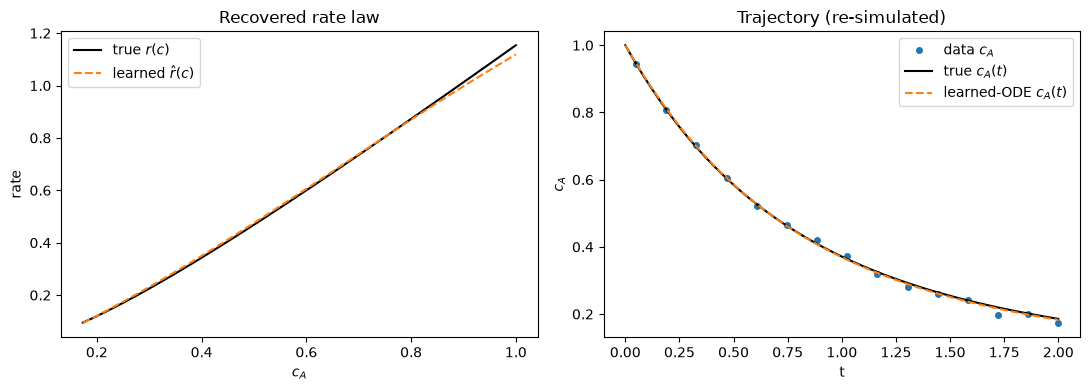

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(c_grid, r_true(c_grid), "k-", label="true $r(c)$")
ax1.plot(c_grid, r_hat(c_grid), "C1--", label="learned $\\hat r(c)$")
ax1.set_xlabel("$c_A$"); ax1.set_ylabel("rate"); ax1.set_title("Recovered rate law")
ax1.legend()

ax2.plot(t_data, yA, "C0o", ms=4, label="data $c_A$")
ax2.plot(truth.t, truth.y[0], "k-", label="true $c_A(t)$")
ax2.plot(learned.t, learned.y[0], "C1--", label="learned-ODE $c_A(t)$")
ax2.set_xlabel("t"); ax2.set_ylabel("$c_A$"); ax2.set_title("Trajectory (re-simulated)")
ax2.legend()
fig.tight_layout()

## Multiple experiments, shared weights

Real data comes from several experiments (different initial conditions). The
surrogate should be *shared* across them while each trajectory gets its own
state block. `fit_trajectories` builds one collocation block per trajectory on
the shared model, all wired to the same right-hand side, so the network weights
are trained jointly — exactly the block structure of the simultaneous approach.


In [7]:
from discopt.dae import Trajectory, fit_trajectories

trajs = []
for k, ca0 in enumerate([1.0, 0.8, 0.6]):
    t, ya, yb = make_data(seed=k, ca0=ca0)
    trajs.append(Trajectory(t_data=t, y_data={"cA": ya, "cB": yb},
                            initial={"cA": ca0, "cB": 0.0}))

m2 = dm.Model("neural_dae_multi")
net2 = TrainableNetwork(m2, [1, 30, 30, 1], activation="softplus", name="rate")


def rhs2(t, s, a, u):
    r = net2(s["cA"])
    return {"cA": -r, "cB": r}


fit = fit_trajectories(m2, trajectories=trajs,
                       states=[("cA", dict(bounds=(0.0, 1.5))),
                               ("cB", dict(bounds=(0.0, 1.5)))],
                       rhs=rhs2, t_span=(0.0, TF), nfe=20, ncp=2)
m2.minimize(fit.least_squares() + 1e-4 * net2.l2_penalty())

res2 = train(m2, initial_solution=fit.warm_start() | net2.initial_values(seed=0),
             options={"max_iter": 3000, "tol": 1e-8})
print(f"{net2.n_parameters()} shared weights, 3 trajectories: "
      f"{res2.status.name} in {res2.iterations} iterations")

1021 shared weights, 3 trajectories: OPTIMAL in 20 iterations


Even at ~1000 weights across three trajectories, the full-space NLP
converges in well under 40 interior-point iterations from a random
initialization — no decomposition needed at this scale. When the problem *does*
grow (many experiments, long horizons), the block-bordered structure here is what
a Schur-complement or consensus decomposition would exploit.


## A kernel surrogate: linear in its parameters

A neural network is not the only choice. A **kernel / Gaussian-process-mean**
expansion $r(x) = \sum_j \alpha_j\, k(x, c_j)$ with fixed centers and lengthscale
is *linear in its trainable coefficients* $\alpha$. That makes the ML block add
no nonconvexity of its own: zero initialization suffices, there are no
weight-symmetry local minima, and conditioning is excellent. The hyperparameters
(centers, lengthscale) stay *outside* the NLP — tune them with a separate
marginal-likelihood or cross-validation loop.


In [8]:
from discopt.nn import TrainableKernelExpansion

m3 = dm.Model("kernel_dae")
ke = TrainableKernelExpansion(m3, centers=np.linspace(0.0, 1.05, 12),
                              lengthscale=0.12, name="rate")

cs3 = ContinuousSet("t", (0.0, TF), nfe=20, ncp=2, scheme="radau")
dae3 = DAEBuilder(m3, cs3)
dae3.add_state("cA", bounds=(0.0, 1.5), initial=CA0)
dae3.add_state("cB", bounds=(0.0, 1.5), initial=CB0)
dae3.set_ode(lambda t, s, a, u: {"cA": -ke(s["cA"]), "cB": ke(s["cA"])})
dv3 = dae3.discretize()
m3.minimize(dae3.least_squares("cA", t_data, yA) + dae3.least_squares("cB", t_data, yB)
            + 1e-4 * ke.l2_penalty())

tp3 = dae3._element_points()
warm3 = {
    dv3["cA"]: np.interp(tp3, np.concatenate([[0], t_data]), np.concatenate([[CA0], yA])),
    dv3["cB"]: np.interp(tp3, np.concatenate([[0], t_data]), np.concatenate([[CB0], yB])),
} | ke.initial_values()
res3 = train(m3, initial_solution=warm3, options={"max_iter": 3000, "tol": 1e-8})
print(f"kernel surrogate ({ke.n_parameters()} coefficients, zero init): "
      f"{res3.status.name} in {res3.iterations} iterations")

kernel surrogate (12 coefficients, zero init): OPTIMAL in 12 iterations


## Closing the loop: train, then freeze, then optimize

The trained surrogate bridges back to the **frozen** embedding path. Once frozen
into a `NetworkDefinition`, the network can be embedded in a *design* or *control*
optimization and solved with discopt's global machinery
{cite:p}`Schweidtmann2019` — the two halves of `discopt.nn` become one workflow.
Here we simply ask: over the operating range, at what $c_A$ is the (learned) rate
maximized?


In [9]:
design = dm.Model("use_frozen_rate")
from discopt.nn import add_predictor

c_in = design.continuous("cA", shape=(1,), lb=0.05, ub=1.0)
rate_out, _formulation = add_predictor(design, c_in, frozen, method="full_space")
design.maximize(rate_out[0])
sol = design.solve()
print(f"learned rate is maximized at cA = {float(np.ravel(sol.value(c_in))[0]):.3f} "
      f"(rate = {float(np.ravel(sol.value(rate_out))[0]):.3f})")

AMP: omitting constraint pred_act_0_0 from the MILP relaxation because it cannot be linearized safely: Cannot linearize FunctionCall: tanh(pred_zhat_0[6][0])


AMP: omitting constraint pred_act_0_1 from the MILP relaxation because it cannot be linearized safely: Cannot linearize FunctionCall: tanh(pred_zhat_0[6][1])


AMP: omitting constraint pred_act_0_2 from the MILP relaxation because it cannot be linearized safely: Cannot linearize FunctionCall: tanh(pred_zhat_0[6][2])


AMP: omitting constraint pred_act_0_3 from the MILP relaxation because it cannot be linearized safely: Cannot linearize FunctionCall: tanh(pred_zhat_0[6][3])


AMP: omitting constraint pred_act_0_4 from the MILP relaxation because it cannot be linearized safely: Cannot linearize FunctionCall: tanh(pred_zhat_0[6][4])


AMP: omitting constraint pred_act_0_5 from the MILP relaxation because it cannot be linearized safely: Cannot linearize FunctionCall: tanh(pred_zhat_0[6][5])


learned rate is maximized at cA = 1.000 (rate = 1.118)


## Any surrogate, not just neural nets

The surrogate is decoupled from the solver: `train` operates on the assembled
model and `fit_trajectories` takes your right-hand side, so the *only* contract a
surrogate must satisfy is the `Surrogate` protocol — a callable
`__call__(x) -> expression` plus `parameters` / `n_parameters` / `l2_penalty` /
`initial_values`. `TrainableNetwork` and `TrainableKernelExpansion` implement it,
but so can anything you write: a Gaussian-process mean, a soft (differentiable)
decision tree, or a *fixed-structure symbolic formula* whose constants are
trained in the NLP.

That last case is the natural bridge to symbolic regression: run a structure
search (PySR / jaxsr) offline to discover the *form* of the unknown term, then
embed that form as a surrogate and fit its constants here — often to global
optimality, which the local optimizers in those tools cannot do. Below, the
"discovered" form is the true Michaelis-Menten structure $r(c)=a\,c^2/(b+c)$; the
NLP recovers its constants $a\approx1.5$, $b\approx0.3$.

In [10]:
from discopt.nn import Surrogate


class RationalRate:
    """r(c) = a * c**2 / (b + c) — a symbolic form with two trainable constants."""

    def __init__(self, model, *, name):
        self.a = model.continuous(f"{name}_a", lb=0.0, ub=10.0)
        self.b = model.continuous(f"{name}_b", lb=1e-3, ub=10.0)

    def __call__(self, c):
        return self.a * c**2 / (self.b + c)

    def parameters(self):
        return [self.a, self.b]

    def n_parameters(self):
        return 2

    def l2_penalty(self):
        return self.a**2 + self.b**2

    def initial_values(self):
        return {self.a: np.array(1.0), self.b: np.array(1.0)}


m4 = dm.Model("symbolic_rate")
rate = RationalRate(m4, name="r")
print("satisfies the Surrogate protocol:", isinstance(rate, Surrogate))

dae4 = DAEBuilder(m4, ContinuousSet("t", (0.0, TF), nfe=20, ncp=2, scheme="radau"))
dae4.add_state("cA", bounds=(0.0, 1.5), initial=CA0)
dae4.add_state("cB", bounds=(0.0, 1.5), initial=CB0)
dae4.set_ode(lambda t, s, a, u: {"cA": -rate(s["cA"]), "cB": rate(s["cA"])})
dv4 = dae4.discretize()
m4.minimize(dae4.least_squares("cA", t_data, yA) + dae4.least_squares("cB", t_data, yB)
            + 1e-6 * rate.l2_penalty())

tp4 = dae4._element_points()
warm4 = {
    dv4["cA"]: np.interp(tp4, np.concatenate([[0], t_data]), np.concatenate([[CA0], yA])),
    dv4["cB"]: np.interp(tp4, np.concatenate([[0], t_data]), np.concatenate([[CB0], yB])),
} | rate.initial_values()

res4 = train(m4, initial_solution=warm4, options={"max_iter": 3000, "tol": 1e-8})
from discopt.warm_start import unflatten_solution
vals = unflatten_solution(m4, res4.x)
print(f"recovered a = {float(vals[rate.a]):.3f} (true 1.5), "
      f"b = {float(vals[rate.b]):.3f} (true 0.3)")

satisfies the Surrogate protocol: True


recovered a = 1.443 (true 1.5), b = 0.263 (true 0.3)


## Summary

- Hybrid physics + ML models train as a **single simultaneous NLP**: collocation
  turns the dynamics into algebraic constraints, and the surrogate's weights are
  ordinary decision variables — no integrator, no adjoints {cite:p}`Lueg2025`.
- `TrainableNetwork` / `TrainableKernelExpansion` emit these surrogates
  symbolically; `fit_trajectories` shares one surrogate across many experiments;
  `train` does the local solve.
- `freeze()` bridges a trained surrogate into the frozen-embedding path, so you
  can then optimize *over* the learned model with global guarantees — closing the
  train-then-deploy loop.

**References.** {cite:t}`Lueg2025`; collocation background {cite:p}`Biegler2010`;
neural ODEs {cite:p}`Chen2018`; frozen NN embedding {cite:p}`Ceccon2022,Anderson2020`;
global optimization over embedded networks {cite:p}`Schweidtmann2019`.
